1. Định nghĩa mạng CNN và Cấu hìnhĐoạn code này xây dựng một kiến trúc CNN cơ bản với 3 khối tích chập (Conv block), phù hợp cho ảnh đầu vào kích thước $128 \times 128$ mà chúng ta đã set ở trên.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x


model = SimpleCNN(num_classes=6).to(device) 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Đang sử dụng thiết bị: cuda


2. Viết vòng lặp Huấn luyện và Đánh giá
Bước này sẽ kết hợp cả quá trình train và tự động validate (đánh giá) sau mỗi epoch để bạn theo dõi được mô hình có đang học tốt hay bị overfitting không.

In [2]:
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

ROOT = Path('.')
DATA_ROOT = ROOT / 'cnn_crops'

CLASS_NAMES = ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']


def _parse_yolo_row(line: str):
    p = line.strip().split()
    if len(p) != 5:
        return None
    cls = int(float(p[0]))
    xc, yc, w, h = map(float, p[1:])
    return cls, xc, yc, w, h


def _to_xyxy(xc, yc, w, h, iw, ih):
    x1 = max(0, int((xc - w / 2) * iw))
    y1 = max(0, int((yc - h / 2) * ih))
    x2 = min(iw, int((xc + w / 2) * iw))
    y2 = min(ih, int((yc + h / 2) * ih))
    return x1, y1, x2, y2


def _find_image(images_dir: Path, stem: str):
    for ext in ('.jpg', '.jpeg', '.png', '.webp'):
        p = images_dir / f'{stem}{ext}'
        if p.exists():
            return p
    return None


def build_crops_if_missing():
    ready = (DATA_ROOT / 'train').exists() and (DATA_ROOT / 'valid').exists()
    if ready and any((DATA_ROOT / 'train').rglob('*.jpg')):
        print('cnn_crops da ton tai, bo qua buoc tao crop')
        return

    print('Dang tao cnn_crops tu nhan YOLO...')
    for split in ['train', 'valid', 'test']:
        img_dir = ROOT / split / 'images'
        lbl_dir = ROOT / split / 'labels'
        out_split = DATA_ROOT / split
        out_split.mkdir(parents=True, exist_ok=True)
        for c in CLASS_NAMES:
            (out_split / c).mkdir(parents=True, exist_ok=True)

        if not img_dir.exists() or not lbl_dir.exists():
            continue

        for lf in lbl_dir.glob('*.txt'):
            img_path = _find_image(img_dir, lf.stem)
            if img_path is None:
                continue

            try:
                img = Image.open(img_path).convert('RGB')
            except Exception:
                continue

            iw, ih = img.size
            for i, line in enumerate(lf.read_text(encoding='utf-8').splitlines()):
                parsed = _parse_yolo_row(line)
                if parsed is None:
                    continue
                cls, xc, yc, w, h = parsed
                if cls < 0 or cls >= len(CLASS_NAMES):
                    continue
                x1, y1, x2, y2 = _to_xyxy(xc, yc, w, h, iw, ih)
                if x2 <= x1 or y2 <= y1:
                    continue
                crop = img.crop((x1, y1, x2, y2))
                crop.save(out_split / CLASS_NAMES[cls] / f'{lf.stem}_{i:03d}.jpg', quality=90)

    print('Da tao xong cnn_crops')


build_crops_if_missing()

IMG_SIZE = 128
BATCH_SIZE = 64 if device.type == 'cuda' else 32
NUM_WORKERS = 0

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
])
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(DATA_ROOT / 'train', transform=train_tfms, allow_empty=True)
val_ds = datasets.ImageFolder(DATA_ROOT / 'valid', transform=val_tfms, allow_empty=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = SimpleCNN(num_classes=len(train_ds.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('So class:', len(train_ds.classes))
print('Class->index:', train_ds.class_to_idx)
print('Train/Valid samples:', len(train_ds), len(val_ds))

cnn_crops da ton tai, bo qua buoc tao crop
So class: 6
Class->index: {'BIODEGRADABLE': 0, 'CARDBOARD': 1, 'GLASS': 2, 'METAL': 3, 'PAPER': 4, 'PLASTIC': 5}
Train/Valid samples: 107265 2957


In [3]:
EPOCHS = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train() # Bật chế độ huấn luyện (kích hoạt Dropout)
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()               
        outputs = model(images)             
        loss = criterion(outputs, labels)   
        
        loss.backward()                     
        optimizer.step()                    
        
        train_loss += loss.item() * images.size(0)
        
        # Tính độ chính xác
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    
    model.eval() # Bật chế độ đánh giá (tắt Dropout)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Không tính gradient trong lúc đánh giá để tiết kiệm bộ nhớ và tăng tốc
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    
    # Lưu lịch sử
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # In kết quả của epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# Lưu trọng số mô hình sau khi train xong
torch.save(model.state_dict(), 'cnn_best_model.pth')
print("Đã hoàn tất huấn luyện và lưu mô hình!")


Epoch [1/20] Train Loss: 0.7291, Train Acc: 0.7463 | Val Loss: 1.2127, Val Acc: 0.5529
Epoch [2/20] Train Loss: 0.6041, Train Acc: 0.7959 | Val Loss: 1.0217, Val Acc: 0.6307
Epoch [3/20] Train Loss: 0.5371, Train Acc: 0.8173 | Val Loss: 0.9005, Val Acc: 0.6662
Epoch [4/20] Train Loss: 0.4894, Train Acc: 0.8330 | Val Loss: 0.8897, Val Acc: 0.6743
Epoch [5/20] Train Loss: 0.4474, Train Acc: 0.8487 | Val Loss: 0.9764, Val Acc: 0.6547
Epoch [6/20] Train Loss: 0.4096, Train Acc: 0.8611 | Val Loss: 0.8743, Val Acc: 0.6967
Epoch [7/20] Train Loss: 0.3793, Train Acc: 0.8715 | Val Loss: 0.8251, Val Acc: 0.7264
Epoch [8/20] Train Loss: 0.3491, Train Acc: 0.8813 | Val Loss: 0.7738, Val Acc: 0.7240
Epoch [9/20] Train Loss: 0.3238, Train Acc: 0.8912 | Val Loss: 0.7630, Val Acc: 0.7396
Epoch [10/20] Train Loss: 0.2991, Train Acc: 0.8992 | Val Loss: 0.9525, Val Acc: 0.7159
Epoch [11/20] Train Loss: 0.2821, Train Acc: 0.9046 | Val Loss: 0.9697, Val Acc: 0.6916
Epoch [12/20] Train Loss: 0.2606, Train A

3. Đánh giá trực quan

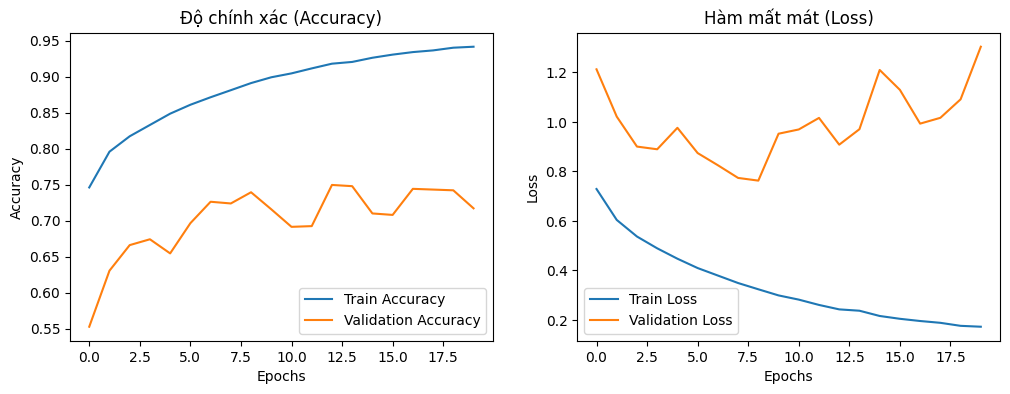

In [4]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Độ chính xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()